### To build Deep Learning Model Pipeline we 2 libraries:

1. Tensorflow - very old library-> need to write every function manually -> Lengthy codes
2. Keras 2.0- is built on top of tensorflow. Dependent on Tensorflow
3. Keras 3.0 - is independent of Tensorflow

In [1]:
!pip install Keras

     ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
      --------------------------------------- 0.0/2.1 MB 1.3 MB/s eta 0:00:02
      --------------------------------------- 0.0/2.1 MB 1.3 MB/s eta 0:00:02
     - -------------------------------------- 0.1/2.1 MB 409.6 kB/s eta 0:00:05
     - -------------------------------------- 0.1/2.1 MB 521.8 kB/s eta 0:00:04
     -- ------------------------------------- 0.1/2.1 MB 467.6 kB/s eta 0:00:05
     -- ------------------------------------- 0.2/2.1 MB 573.4 kB/s eta 0:00:04
     ---- ----------------------------------- 0.2/2.1 MB 762.6 kB/s eta 0:00:03
     ---- ----------------------------------- 0.3/2.1 MB 714.4 kB/s eta 0:00:03
     -------- ------------------------------- 0.4/2.1 MB 1.1 MB/s eta 0:00:02
     --------- ------------------------------ 0.5/2.1 MB 1.2 MB/s eta 0:00:02
     ----------- ---------------------------- 0.6/2.1 MB 1.2 MB/s eta 0:00:02
     ------------------- -------------------- 1.0/2.1 MB 1.


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install tensorflow

     ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
     -------------------------------------- 0.0/350.6 MB 660.6 kB/s eta 0:08:51
     -------------------------------------- 0.0/350.6 MB 660.6 kB/s eta 0:08:51
     -------------------------------------- 0.0/350.6 MB 660.6 kB/s eta 0:08:51
     -------------------------------------- 0.0/350.6 MB 164.3 kB/s eta 0:35:34
     -------------------------------------- 0.1/350.6 MB 218.8 kB/s eta 0:26:43
     -------------------------------------- 0.1/350.6 MB 291.5 kB/s eta 0:20:03
     -------------------------------------- 0.1/350.6 MB 291.5 kB/s eta 0:20:03
     -------------------------------------- 0.1/350.6 MB 291.5 kB/s eta 0:20:03
     -------------------------------------- 0.1/350.6 MB 257.8 kB/s eta 0:22:40
     -------------------------------------- 0.2/350.6 MB 368.6 kB/s eta 0:15:51
     -------------------------------------- 0.2/350.6 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 7.36.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## import necasariry libraries

In [31]:
import keras
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from keras.models import Sequential
from keras.layers import Flatten,Dense

## DATA COLLECTION

In [11]:
 (x_train, y_train), (x_test, y_test)= keras.datasets.mnist.load_data(path="mnist.npz")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## DATA UNDERSTANDING

In [19]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [20]:
x_test.shape,x_train.shape

((10000, 28, 28), (60000, 28, 28))

In [21]:
y_test.shape,y_train.shape

((10000,), (60000,))

## data preparation

## Lets normalize this for faster processing

In [17]:
x_train=x_train/255.0
x_test=x_test/255.0

In [18]:
x_train.min(),x_test.max()

(0.0, 1.0)

## Lets see how the image looks like

In [26]:
pd.set_option('display.max_columns', 30)

In [27]:
pd.DataFrame(x_train[10000])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0,0,0,0,0,0,0


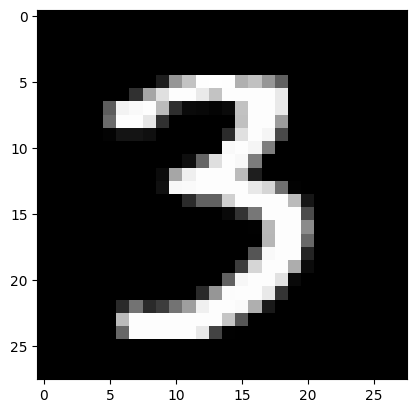

In [29]:
plt.imshow(x_train[10000],cmap='grey')
plt.show()

## MODEL BUILDING

In [38]:
model=Sequential()
model.add(layer=Flatten())
model.add(Dense(units=100,activation='relu'))
model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=10,activation='softmax'))
#model.summary()

In [47]:
model.compile(
   optimizer='rmsprop',
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"])


## MODEL TRAINING || MODEL TESTING || MODEL EVALUATION

In [53]:
model.fit( x=x_train,y=y_train,batch_size=32,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.9219 - sparse_categorical_accuracy: 0.7454 - val_loss: 0.9692 - val_sparse_categorical_accuracy: 0.7367
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.8877 - sparse_categorical_accuracy: 0.7504 - val_loss: 1.0341 - val_sparse_categorical_accuracy: 0.7541
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.9004 - sparse_categorical_accuracy: 0.7551 - val_loss: 1.0120 - val_sparse_categorical_accuracy: 0.7532
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.8659 - sparse_categorical_accuracy: 0.7640 - val_loss: 1.0014 - val_sparse_categorical_accuracy: 0.7829
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.8606 - sparse_categorical_accuracy: 0.7657 - val_loss: 0.9443 - val_sparse_categorical_accuracy: 0.7367
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.8643 - sparse_categorical_accuracy: 0.7643 - val_loss: 1.5032 - val_sparse_categorical_accuracy:

In [54]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)                  │ (32, 784)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (32, 100)                   │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (32, 30)                    │           3,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (32, 10)                    │             310 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 163,682 (639.39 KB)

 Trainable params: 81,840 (319.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,842 (319.70 KB)

## Manual model predection

In [56]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [58]:
y_test[400]

2

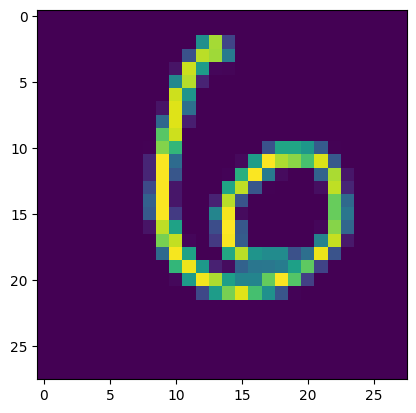

In [59]:
plt.imshow(x_test[100])

In [63]:

np.argmax(y_pred[100])

6

## Final Point: Lets test for outside new data

## Step 1:lets take out the model intelligence

In [64]:
model.save('digits_color.h5')

## step 2:image load

In [97]:
from PIL import Image
img_path=r"C:\Users\sathy\Downloads\download.webp"
image=Image.open(img_path).convert('L').resize((28, 28))
image=np.array(image)
print(image.size)

784


In [98]:
image


array([[ 26,  26,  26,  26,  26,  28,  29,  26,  26,  28,  28,  27,  27,
         26,  26,  26,  29,  27,  26,  26,  29,  26,  26,  26,  26,  26,
         27,  27],
       [ 26,  29,  27,  26,  26,  28,  26,  26,  26,  26,  26,  28,  29,
         26,  26,  27,  26,  25,  25,  26,  26,  26,  28,  27,  26,  26,
         30,  27],
       [ 26,  27,  26,  28,  27,  26,  26,  29,  27,  26,  26,  28,  26,
         26,  25,  31,  36,  38,  41,  31,  25,  27,  28,  26,  26,  26,
         27,  27],
       [ 26,  26,  28,  30,  26,  26,  26,  27,  26,  27,  27,  26,  26,
         28,  37,  97, 133, 129, 129,  63,  22,  26,  26,  27,  29,  26,
         26,  27],
       [ 26,  26,  27,  26,  27,  28,  26,  26,  27,  30,  27,  26,  25,
         34,  81, 108, 129, 122, 127,  62,  24,  26,  26,  28,  26,  26,
         27,  26],
       [ 28,  28,  26,  26,  29,  28,  26,  26,  26,  26,  27,  28,  25,
         78,  91, 101, 116, 109, 128,  69,  21,  27,  27,  26,  26,  29,
         29,  27],
       [ 2

In [104]:
predict_image()

(28, 28)


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(28, 28), dtype=float32). Expected shape (32, 28, 28), but input has incompatible shape (28, 28)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(28, 28), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

## Step 3: Lets do the prediction

In [84]:
from keras.models import load_model
digit_brain=load_model('digits_color.h5')

In [109]:
def predict_image(image):
    image=image/255.0
    image=np.expand_dims(image,axis=0)
    print(image.shape)
    prediction = digit_brain.predict(image)
    return np.argmax(prediction)

In [110]:
predict_image(image)

(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


8

# THE END!!